In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt

In [2]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 9
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = 'Arial'

In [3]:
hydrogenResultsFileName = 'hydrogen climate change breakdown results.xlsx'
ammoniaResultsFileName = 'ammonia climate change breakdown results.xlsx'
methanolResultsFileName = 'methanol climate change breakdown results.xlsx'
ethyleneResultsFileName = 'ethylene climate change breakdown results.xlsx'

In [4]:
hydrogenBAUDF = pd.read_excel(os.path.join('..', 'Results', 'Phase 2', 'Hydrogen', hydrogenResultsFileName), sheet_name = 'hydrogenBAU', index_col = 0)
hydrogenBAUWOElecDF = pd.read_excel(os.path.join('..', 'Results', 'Phase 2', 'Hydrogen', hydrogenResultsFileName), sheet_name = 'hydrogenBAUWOElec', index_col = 0)
hydrogenBlueWOElecDF = pd.read_excel(os.path.join('..', 'Results', 'Phase 2', 'Hydrogen', hydrogenResultsFileName), sheet_name = 'hydrogenBlueWOElec', index_col = 0)
hydrogenSolarDF = pd.read_excel(os.path.join('..', 'Results', 'Phase 2', 'Hydrogen', hydrogenResultsFileName), sheet_name = 'hydrogenSolar', index_col = 0)
hydrogenWindDF = pd.read_excel(os.path.join('..', 'Results', 'Phase 2', 'Hydrogen', hydrogenResultsFileName), sheet_name = 'hydrogenWind', index_col = 0)

In [5]:
ammoniaBAUDF = pd.read_excel(os.path.join('..', 'Results', 'Phase 2', 'Ammonia', ammoniaResultsFileName), sheet_name = 'ammoniaBAU', index_col = 0)
ammoniaBlueDF = pd.read_excel(os.path.join('..', 'Results', 'Phase 2', 'Ammonia', ammoniaResultsFileName), sheet_name = 'ammoniaBlue', index_col = 0)
ammoniaSolarDF = pd.read_excel(os.path.join('..', 'Results', 'Phase 2', 'Ammonia', ammoniaResultsFileName), sheet_name = 'ammoniaSolar', index_col = 0)
ammoniaWindDF = pd.read_excel(os.path.join('..', 'Results', 'Phase 2', 'Ammonia', ammoniaResultsFileName), sheet_name = 'ammoniaWind', index_col = 0)

In [6]:
methanolBAUDF = pd.read_excel(os.path.join('..', 'Results', 'Phase 2', 'Methanol', methanolResultsFileName), sheet_name = 'methanolBAU', index_col = 0)
methanolBlueDF = pd.read_excel(os.path.join('..', 'Results', 'Phase 2', 'Methanol', methanolResultsFileName), sheet_name = 'methanolBlue', index_col = 0)
methanolSolarDF = pd.read_excel(os.path.join('..', 'Results', 'Phase 2', 'Methanol', methanolResultsFileName), sheet_name = 'methanolSolar', index_col = 0)
methanolWindDF = pd.read_excel(os.path.join('..', 'Results', 'Phase 2', 'Methanol', methanolResultsFileName), sheet_name = 'methanolWind', index_col = 0)

In [7]:
ethyleneBAUDF = pd.read_excel(os.path.join('..', 'Results', 'Phase 2', 'Ethylene', ethyleneResultsFileName), sheet_name = 'ethyleneBAU', index_col = 0)
ethyleneBlueDF = pd.read_excel(os.path.join('..', 'Results', 'Phase 2', 'Ethylene', ethyleneResultsFileName), sheet_name = 'ethyleneBlue', index_col = 0)
ethyleneSolarDF = pd.read_excel(os.path.join('..', 'Results', 'Phase 2', 'Ethylene', ethyleneResultsFileName), sheet_name = 'ethyleneSolar', index_col = 0)
ethyleneWindDF = pd.read_excel(os.path.join('..', 'Results', 'Phase 2', 'Ethylene', ethyleneResultsFileName), sheet_name = 'ethyleneWind', index_col = 0)

In [8]:
"""hydrogenDF = pd.concat([hydrogenBAUDF, hydrogenBAUDF, hydrogenSolarDF])
hydrogenDF = hydrogenDF.fillna(0)
hydrogenRCP6DF = hydrogenDF[hydrogenDF['database'].str.contains(' SSP2-RCP6')]
hydrogenRCP26DF = hydrogenDF[hydrogenDF['database'].str.contains(' SSP2-RCP26') | hydrogenDF['database'].str.contains(' SSP2-RCP6 2020')]
hydrogenRCP19DF = hydrogenDF[hydrogenDF['database'].str.contains(' SSP2-RCP19') | hydrogenDF['database'].str.contains(' SSP2-RCP6 2020')]"""


"hydrogenDF = pd.concat([hydrogenBAUDF, hydrogenBAUDF, hydrogenSolarDF])\nhydrogenDF = hydrogenDF.fillna(0)\nhydrogenRCP6DF = hydrogenDF[hydrogenDF['database'].str.contains(' SSP2-RCP6')]\nhydrogenRCP26DF = hydrogenDF[hydrogenDF['database'].str.contains(' SSP2-RCP26') | hydrogenDF['database'].str.contains(' SSP2-RCP6 2020')]\nhydrogenRCP19DF = hydrogenDF[hydrogenDF['database'].str.contains(' SSP2-RCP19') | hydrogenDF['database'].str.contains(' SSP2-RCP6 2020')]"

In [9]:
"""def hydrogen_breakdown_plots(originalDF, ax):
    xPts = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

    df_plot_new = pd.DataFrame()
    df_plot = originalDF.drop(['name', 'database'], axis = 1)
    columns_to_drop = [col for col in df_plot.columns if 'hydrogen' in col]
    df_plot = df_plot.drop(columns = columns_to_drop)
    naturalGasCols = df_plot.columns[df_plot.columns.str.contains('natural gas')]
    waterCols = df_plot.columns[df_plot.columns.str.contains('market for water, deionised')]
    directEmissionsCols = df_plot.columns[df_plot.columns.str.contains('direct emissions')]
    gridElectricityCols = df_plot.columns[df_plot.columns.str.contains('market group for electricity, high voltage')]
    renewableElecCols = df_plot.columns[df_plot.columns.str.contains('photovoltaic') | df_plot.columns.str.contains('onshore')]
    otherCols = list(set(df_plot.columns) - set(naturalGasCols) - set(waterCols) - set(directEmissionsCols) - set(gridElectricityCols) - set(renewableElecCols))

    df_plot_new['Natural gas'] = df_plot[naturalGasCols].sum(axis = 1)  
    df_plot_new['Water'] = df_plot[waterCols].sum(axis = 1)  
    df_plot_new['Grid electricity'] = df_plot[gridElectricityCols].sum(axis = 1)  
    df_plot_new['Renewable electricity'] = df_plot[renewableElecCols].sum(axis = 1)  
    df_plot_new['Other utilities'] = df_plot[otherCols].sum(axis = 1)  
    df_plot_new['Direct emissions'] = df_plot[directEmissionsCols].sum(axis = 1)  

    # Rearrange the DataFrame to match the desired order
    new_order = []
    num_groups = len(df_plot_new['Natural gas']) // 3
    for i in range(num_groups):
        new_order.extend([i + num_groups * j for j in range(3)])

    df_rearranged = df_plot_new.iloc[new_order]
    
    colors = ['#808080', '#167f99', '#fb7b71', '#a9d898', '#b71205', '#a78dd8']
    df_plot_new.plot(kind = 'bar', stacked = True, ax = ax, color = colors)
    ax.scatter(xPts, df_plot_new.sum(axis = 1), facecolor = 'yellow', edgecolors = '#808080', s = 15, linewidths = 0.4)
    ax.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
    ax.axvline(x = 3.5, color = '#808080', linestyle = '--', linewidth = 0.5)
    ax.axvline(x = 7.5, color = '#808080', linestyle = '--', linewidth = 0.5)
    ax.text(1.5, 12, 'Fossil', ha = 'center', color = '#808080')
    ax.text(5.5, 12, 'Solar', ha = 'center', color = '#808080')
    ax.text(9.5, 12, 'Wind', ha = 'center', color = '#808080') 
    ax.legend([], frameon = False)
    ax.set_ylim(-1, 13)"""

"def hydrogen_breakdown_plots(originalDF, ax):\n    xPts = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]\n\n    df_plot_new = pd.DataFrame()\n    df_plot = originalDF.drop(['name', 'database'], axis = 1)\n    columns_to_drop = [col for col in df_plot.columns if 'hydrogen' in col]\n    df_plot = df_plot.drop(columns = columns_to_drop)\n    naturalGasCols = df_plot.columns[df_plot.columns.str.contains('natural gas')]\n    waterCols = df_plot.columns[df_plot.columns.str.contains('market for water, deionised')]\n    directEmissionsCols = df_plot.columns[df_plot.columns.str.contains('direct emissions')]\n    gridElectricityCols = df_plot.columns[df_plot.columns.str.contains('market group for electricity, high voltage')]\n    renewableElecCols = df_plot.columns[df_plot.columns.str.contains('photovoltaic') | df_plot.columns.str.contains('onshore')]\n    otherCols = list(set(df_plot.columns) - set(naturalGasCols) - set(waterCols) - set(directEmissionsCols) - set(gridElectricityCols) - set(renewableEl

In [10]:
"""fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (fig_length[2], fig_height*0.8))

xPts = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

hydrogen_breakdown_plots(hydrogenRCP6DF, ax1)
ax1.xaxis.set_ticks_position('none')
ax1.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax1.set_title('a  RCP6', color = 'black', fontsize = fontsize_title, fontweight = 'bold')
ax1.set_xticks([])

hydrogen_breakdown_plots(hydrogenRCP26DF, ax2)
ax2.xaxis.set_ticks_position('none')
ax2.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax2.set_title('b  RCP2.6', color = 'black', fontsize = fontsize_title, fontweight = 'bold')
ax2.set_xticks([])

hydrogen_breakdown_plots(hydrogenRCP19DF, ax3)
ax3.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax3.set_title('c  RCP1.9', color = 'black', fontsize = fontsize_title, fontweight = 'bold')
ax3.set_xticks(xPts)  
ax3.set_xticklabels(['2020', '2030', '2040', '2050']*3, rotation = 45, ha = 'center')  

handles, labels = ax3.get_legend_handles_labels()
legend = fig.legend(handles, labels, loc = 'lower center', bbox_to_anchor = (0.5, -0.05), frameon = False, ncol = 3, handletextpad = 0.1)
for i in range(0, len(legend.legend_handles)):
    legend.legend_handles[i].set_width(12)

#filepath = os.path.join('..', 'Plots', 'Breakdown', 'Hydrogen SSP2 GLO')
#plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
#plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)"""

"fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (fig_length[2], fig_height*0.8))\n\nxPts = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]\n\nhydrogen_breakdown_plots(hydrogenRCP6DF, ax1)\nax1.xaxis.set_ticks_position('none')\nax1.set_ylabel('GWP [kg CO$_\\mathrm{2}$-eq kg$^\\mathrm{-1}$]')\nax1.set_title('a  RCP6', color = 'black', fontsize = fontsize_title, fontweight = 'bold')\nax1.set_xticks([])\n\nhydrogen_breakdown_plots(hydrogenRCP26DF, ax2)\nax2.xaxis.set_ticks_position('none')\nax2.set_ylabel('GWP [kg CO$_\\mathrm{2}$-eq kg$^\\mathrm{-1}$]')\nax2.set_title('b  RCP2.6', color = 'black', fontsize = fontsize_title, fontweight = 'bold')\nax2.set_xticks([])\n\nhydrogen_breakdown_plots(hydrogenRCP19DF, ax3)\nax3.set_ylabel('GWP [kg CO$_\\mathrm{2}$-eq kg$^\\mathrm{-1}$]')\nax3.set_title('c  RCP1.9', color = 'black', fontsize = fontsize_title, fontweight = 'bold')\nax3.set_xticks(xPts)  \nax3.set_xticklabels(['2020', '2030', '2040', '2050']*3, rotation = 45, ha = 'center')  \n\nhandles, 

In [11]:
hydrogenWOElecDF = pd.concat([hydrogenBAUWOElecDF, hydrogenBlueWOElecDF, hydrogenSolarDF, hydrogenWindDF])
hydrogenWOElecDF = hydrogenWOElecDF.fillna(0)
hydrogenRCP6DFWOElec = hydrogenWOElecDF[hydrogenWOElecDF['database'].str.contains(' SSP2-RCP6')]
hydrogenRCP26DFWOElec = hydrogenWOElecDF[hydrogenWOElecDF['database'].str.contains(' SSP2-RCP26') | hydrogenWOElecDF['database'].str.contains(' SSP2-RCP6 2020')]
hydrogenRCP19DFWOElec = hydrogenWOElecDF[hydrogenWOElecDF['database'].str.contains(' SSP2-RCP19') | hydrogenWOElecDF['database'].str.contains(' SSP2-RCP6 2020')]

In [12]:
def hydrogen_wo_elec_breakdown_plots(originalDF, ax):
    xPts = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

    df_plot_new = pd.DataFrame()
    df_plot = originalDF.drop(['name', 'database'], axis = 1)
    columns_to_drop = [col for col in df_plot.columns if 'hydrogen' in col]
    df_plot = df_plot.drop(columns = columns_to_drop)
    naturalGasCols = df_plot.columns[df_plot.columns.str.contains('natural gas')]
    waterCols = df_plot.columns[df_plot.columns.str.contains('market for water, deionised')]
    directEmissionsCols = df_plot.columns[df_plot.columns.str.contains('direct emissions')]
    gridElectricityCols = df_plot.columns[df_plot.columns.str.contains('market group for electricity, high voltage')]
    renewableElecCols = df_plot.columns[df_plot.columns.str.contains('photovoltaic') | df_plot.columns.str.contains('onshore')]
    otherCols = list(set(df_plot.columns) - set(naturalGasCols) - set(waterCols) - set(directEmissionsCols) - set(gridElectricityCols) - set(renewableElecCols))

    df_plot_new['Natural gas'] = df_plot[naturalGasCols].sum(axis = 1)  
    df_plot_new['Water'] = df_plot[waterCols].sum(axis = 1)  
    df_plot_new['Grid electricity'] = df_plot[gridElectricityCols].sum(axis = 1)  
    df_plot_new['Renewable electricity'] = df_plot[renewableElecCols].sum(axis = 1)  
    df_plot_new['Other utilities'] = df_plot[otherCols].sum(axis = 1)  
    df_plot_new['Direct emissions'] = df_plot[directEmissionsCols].sum(axis = 1)  

    # Rearrange the DataFrame to match the desired order
    new_order = []
    num_groups = len(df_plot_new['Natural gas']) // 3
    for i in range(num_groups):
        new_order.extend([i + num_groups * j for j in range(3)])

    df_rearranged = df_plot_new.iloc[new_order]
    
    colors = ['#808080', '#167f99', '#fb7b71', '#a9d898', '#b71205', '#a78dd8']
    df_plot_new.plot(kind = 'bar', stacked = True, ax = ax, color = colors)
    ax.scatter(xPts, df_plot_new.sum(axis = 1), facecolor = 'yellow', edgecolors = '#808080', s = 15, linewidths = 0.4)
    ax.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
    ax.axvline(x = 3.5, color = '#808080', linestyle = '--', linewidth = 0.5)
    ax.axvline(x = 7.5, color = '#808080', linestyle = '--', linewidth = 0.5)
    ax.axvline(x = 11.5, color = '#808080', linestyle = '--', linewidth = 0.5)
    ax.text(1.5, 12, 'Fossil', ha = 'center', color = '#808080')
    ax.text(5.5, 12, 'Blue', ha = 'center', color = '#808080')
    ax.text(9.5, 12, 'Solar', ha = 'center', color = '#808080')
    ax.text(13.5, 12, 'Wind', ha = 'center', color = '#808080') 
    ax.legend([], frameon = False)
    ax.set_ylim(0.01, 13)

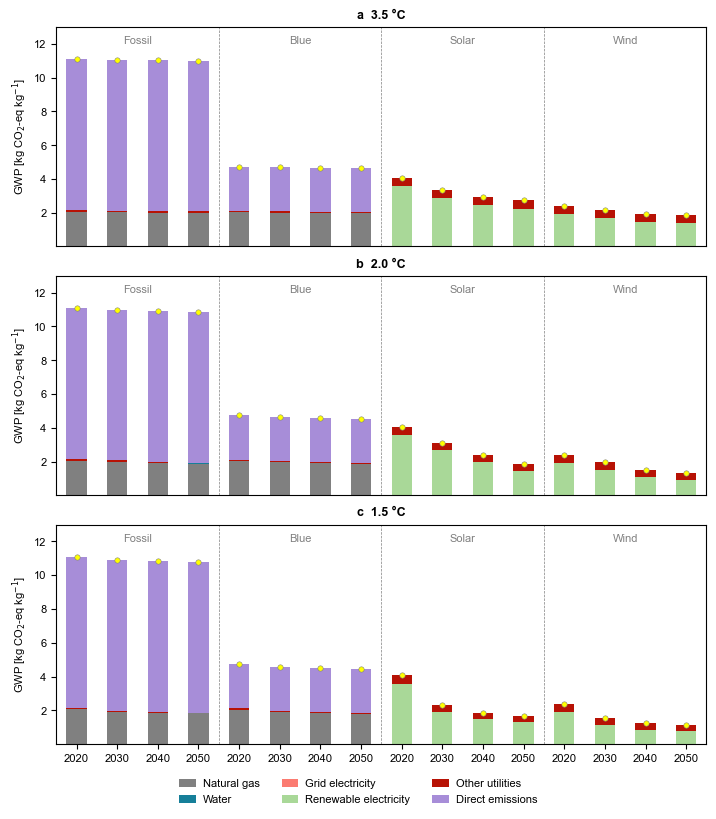

In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (fig_length[2], fig_height*0.8))

xPts = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

hydrogen_wo_elec_breakdown_plots(hydrogenRCP6DFWOElec, ax1)
ax1.xaxis.set_ticks_position('none')
ax1.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax1.set_title('a  3.5 °C', color = 'black', fontsize = fontsize_title, fontweight = 'bold')
ax1.set_xticks([])

hydrogen_wo_elec_breakdown_plots(hydrogenRCP26DFWOElec, ax2)
ax2.xaxis.set_ticks_position('none')
ax2.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax2.set_title('b  2.0 °C', color = 'black', fontsize = fontsize_title, fontweight = 'bold')
ax2.set_xticks([])

hydrogen_wo_elec_breakdown_plots(hydrogenRCP19DFWOElec, ax3)
ax3.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax3.set_title('c  1.5 °C', color = 'black', fontsize = fontsize_title, fontweight = 'bold')
ax3.set_xticks(xPts)  
ax3.set_xticklabels(['2020', '2030', '2040', '2050']*4, rotation = 0, ha = 'center')  

handles, labels = ax3.get_legend_handles_labels()
legend = fig.legend(handles, labels, loc = 'lower center', bbox_to_anchor = (0.5, -0.05), frameon = False, ncol = 3, handletextpad = 0.1)
for i in range(0, len(legend.legend_handles)):
    legend.legend_handles[i].set_width(12)

filepath = os.path.join('..', 'Plots', 'Phase 2', 'Breakdown', 'Hydrogen image SSP2 GLO')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

In [14]:
ammoniaDF = pd.concat([ammoniaBAUDF, ammoniaBlueDF, ammoniaSolarDF, ammoniaWindDF])
ammoniaDF = ammoniaDF.fillna(0)
ammoniaRCP6DF = ammoniaDF[ammoniaDF['database'].str.contains(' SSP2-RCP6')]
ammoniaRCP26DF = ammoniaDF[ammoniaDF['database'].str.contains(' SSP2-RCP26') | ammoniaDF['database'].str.contains(' SSP2-RCP6 2020')]
ammoniaRCP19DF = ammoniaDF[ammoniaDF['database'].str.contains(' SSP2-RCP19') | ammoniaDF['database'].str.contains(' SSP2-RCP6 2020')]

In [15]:
def ammonia_breakdown_plots(originalDF, ax):
    xPts = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

    df_plot_new = pd.DataFrame()
    df_plot = originalDF.drop(['name', 'database'], axis = 1)
    columns_to_drop = [col for col in df_plot.columns if 'ammonia' in col]
    df_plot = df_plot.drop(columns = columns_to_drop)
    naturalGasCols = df_plot.columns[df_plot.columns.str.contains('natural gas')]
    waterCols = df_plot.columns[df_plot.columns.str.contains('market for tap water')]
    directEmissionsCols = df_plot.columns[df_plot.columns.str.contains('direct emissions')]
    gridElectricityCols = df_plot.columns[df_plot.columns.str.contains('market group for electricity, high voltage')]
    nitrogenCols = df_plot.columns[df_plot.columns.str.contains('nitrogen')]
    greenHydrogenCols = df_plot.columns[df_plot.columns.str.contains('hydrogen')]
    otherCols = list(set(df_plot.columns) - set(naturalGasCols) - set(waterCols) - set(directEmissionsCols) - set(gridElectricityCols) - set(greenHydrogenCols) - set(nitrogenCols))

    df_plot_new['Natural gas'] = df_plot[naturalGasCols].sum(axis = 1)  
    df_plot_new['Water'] = df_plot[waterCols].sum(axis = 1)  
    df_plot_new['Hydrogen'] = df_plot[greenHydrogenCols].sum(axis = 1) 
    df_plot_new['Nitrogen'] = df_plot[nitrogenCols].sum(axis = 1) 
    df_plot_new['Grid electricity'] = df_plot[gridElectricityCols].sum(axis = 1)  
    df_plot_new['Other utilities'] = df_plot[otherCols].sum(axis = 1)  
    df_plot_new['Direct emissions'] = df_plot[directEmissionsCols].sum(axis = 1)  

    # Rearrange the DataFrame to match the desired order
    new_order = []
    num_groups = len(df_plot_new['Natural gas']) // 3
    for i in range(num_groups):
        new_order.extend([i + num_groups * j for j in range(3)])

    df_rearranged = df_plot_new.iloc[new_order]
    
    colors = ['#808080', '#167f99', '#a9d898', '#6dd2ea', '#fb7b71', '#b71205', '#a78dd8']
    df_plot_new.plot(kind = 'bar', stacked = True, ax = ax, color = colors)
    ax.scatter(xPts, df_plot_new.sum(axis = 1), facecolor = 'yellow', edgecolors = '#808080', s = 15, linewidths = 0.4)
    ax.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
    ax.axvline(x = 3.5, color = '#808080', linestyle = '--', linewidth = 0.5)
    ax.axvline(x = 7.5, color = '#808080', linestyle = '--', linewidth = 0.5)
    ax.axvline(x = 11.5, color = '#808080', linestyle = '--', linewidth = 0.5)
    ax.text(1.5, 3, 'Fossil', ha = 'center', color = '#808080')
    ax.text(5.5, 3, 'Blue', ha = 'center', color = '#808080')
    ax.text(9.5, 3, 'Solar', ha = 'center', color = '#808080') 
    ax.text(13.5, 3, 'Wind', ha = 'center', color = '#808080') 
    ax.legend([], frameon = False)
    ax.set_ylim(-0.1, 3.3)

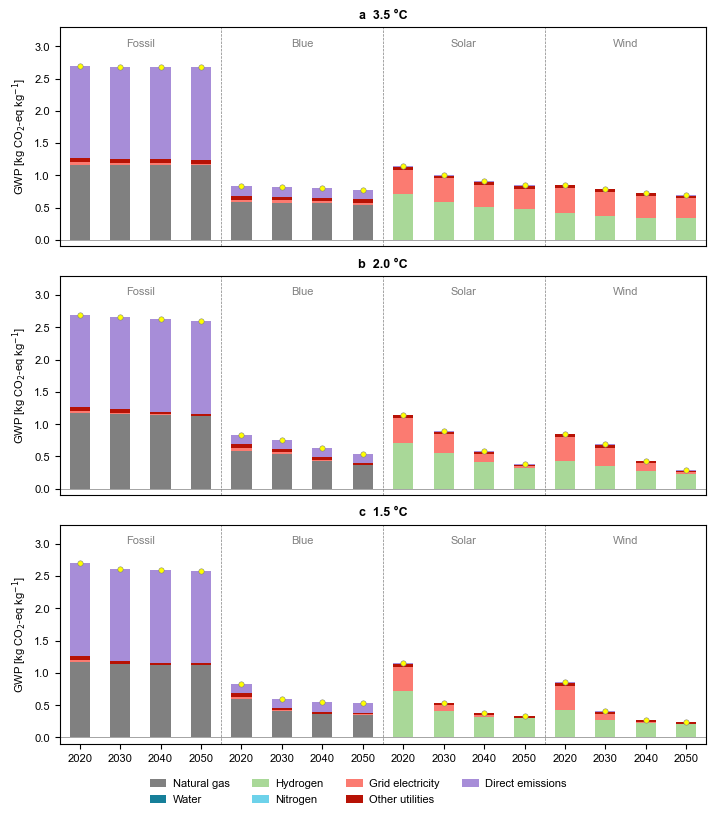

In [16]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (fig_length[2], fig_height*0.8))

xPts = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

ammonia_breakdown_plots(ammoniaRCP6DF, ax1)
ax1.xaxis.set_ticks_position('none')
ax1.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax1.set_title('a  3.5 °C', color = 'black', fontsize = fontsize_title, fontweight = 'bold')
ax1.set_xticks([])

ammonia_breakdown_plots(ammoniaRCP26DF, ax2)
ax2.xaxis.set_ticks_position('none')
ax2.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax2.set_title('b  2.0 °C', color = 'black', fontsize = fontsize_title, fontweight = 'bold')
ax2.set_xticks([])

ammonia_breakdown_plots(ammoniaRCP19DF, ax3)
ax3.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax3.set_title('c  1.5 °C', color = 'black', fontsize = fontsize_title, fontweight = 'bold')
ax3.set_xticks(xPts)  
ax3.set_xticklabels(['2020', '2030', '2040', '2050']*4, rotation = 0, ha = 'center')  

handles, labels = ax3.get_legend_handles_labels()
legend = fig.legend(handles, labels, loc = 'lower center', bbox_to_anchor = (0.5, -0.05), frameon = False, ncol = 4, handletextpad = 0.1)
for i in range(0, len(legend.legend_handles)):
    legend.legend_handles[i].set_width(12)

filepath = os.path.join('..', 'Plots', 'Phase 2', 'Breakdown', 'Ammonia image SSP2 GLO')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

In [17]:
methanolDF = pd.concat([methanolBAUDF, methanolBlueDF, methanolSolarDF, methanolWindDF])
methanolDF = methanolDF.fillna(0)
methanolRCP6DF = methanolDF[methanolDF['database'].str.contains(' SSP2-RCP6')]
methanolRCP26DF = methanolDF[methanolDF['database'].str.contains(' SSP2-RCP26') | methanolDF['database'].str.contains(' SSP2-RCP6 2020')]
methanolRCP19DF = methanolDF[methanolDF['database'].str.contains(' SSP2-RCP19') | methanolDF['database'].str.contains(' SSP2-RCP6 2020')]
methanolRemindRCP6DF = methanolDF[methanolDF['database'].str.contains('remind SSP2-RCP6') | methanolDF['database'].str.contains(' SSP2-RCP6 2020')]
methanolRemindRCP26DF = methanolDF[methanolDF['database'].str.contains('remind SSP2-RCP26') | methanolDF['database'].str.contains(' SSP2-RCP6 2020')]
methanolRemindRCP19DF = methanolDF[methanolDF['database'].str.contains('remind SSP2-RCP19') | methanolDF['database'].str.contains(' SSP2-RCP6 2020')]

In [18]:
def methanol_breakdown_plots(originalDF, ax):
    xPts = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

    df_plot_new = pd.DataFrame()
    df_plot = originalDF.drop(['name', 'database'], axis = 1)
    columns_to_drop = [col for col in df_plot.columns if 'methanol, BAU' in col or 'methanol synthesis' in col or 'methanol, blue' in col]
    df_plot = df_plot.drop(columns = columns_to_drop)
    naturalGasCols = df_plot.columns[df_plot.columns.str.contains('natural gas')]
    waterCols = df_plot.columns[df_plot.columns.str.contains('market for tap water') | df_plot.columns.str.contains('market for water, deionised')]
    directEmissionsCols = df_plot.columns[df_plot.columns.str.contains('direct emissions')]
    gridElectricityCols = df_plot.columns[df_plot.columns.str.contains('market group for electricity, high voltage') | df_plot.columns.str.contains('market group for electricity, low voltage')]
    nitrogenCols = df_plot.columns[df_plot.columns.str.contains('carbon dioxide')]
    greenHydrogenCols = df_plot.columns[df_plot.columns.str.contains('hydrogen')]
    otherCols = list(set(df_plot.columns) - set(naturalGasCols) - set(waterCols) - set(directEmissionsCols) - set(gridElectricityCols) - set(greenHydrogenCols) - set(nitrogenCols))

    df_plot_new['Natural gas'] = df_plot[naturalGasCols].sum(axis = 1)  
    df_plot_new['Water'] = df_plot[waterCols].sum(axis = 1)  
    df_plot_new['Hydrogen'] = df_plot[greenHydrogenCols].sum(axis = 1) 
    df_plot_new['Carbon dioxide'] = df_plot[nitrogenCols].sum(axis = 1) 
    df_plot_new['Grid electricity'] = df_plot[gridElectricityCols].sum(axis = 1)  
    df_plot_new['Other utilities'] = df_plot[otherCols].sum(axis = 1)  
    df_plot_new['Direct emissions'] = df_plot[directEmissionsCols].sum(axis = 1)  

    # Rearrange the DataFrame to match the desired order
    new_order = []
    num_groups = len(df_plot_new['Natural gas']) // 3
    for i in range(num_groups):
        new_order.extend([i + num_groups * j for j in range(3)])

    df_rearranged = df_plot_new.iloc[new_order]
    
    colors = ['#808080', '#167f99', '#a9d898', '#6dd2ea', '#fb7b71', '#b71205', '#a78dd8']
    df_plot_new.plot(kind = 'bar', stacked = True, ax = ax, color = colors)
    ax.scatter(xPts, df_plot_new.sum(axis = 1), facecolor = 'yellow', edgecolors = '#808080', s = 15, linewidths = 0.4)
    ax.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
    ax.axvline(x = 3.5, color = '#808080', linestyle = '--', linewidth = 0.5)
    ax.axvline(x = 7.5, color = '#808080', linestyle = '--', linewidth = 0.5)
    ax.axvline(x = 11.5, color = '#808080', linestyle = '--', linewidth = 0.5)
    ax.text(1.5, 1.0, 'Fossil', ha = 'center', color = '#808080')
    ax.text(5.5, 1.0, 'Blue', ha = 'center', color = '#808080')
    ax.text(9.5, 1.0, 'Solar', ha = 'center', color = '#808080')
    ax.text(13.5, 1.0, 'Wind', ha = 'center', color = '#808080') 
    ax.legend([], frameon = False)
    ax.set_ylim(-1.7, 1.3)

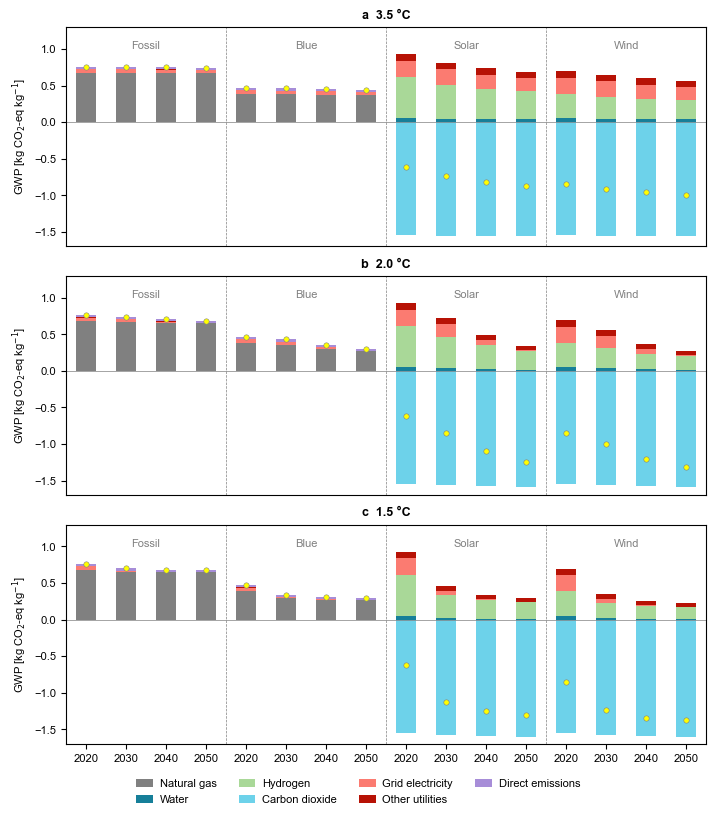

In [19]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (fig_length[2], fig_height*0.8))

xPts = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

methanol_breakdown_plots(methanolRCP6DF, ax1)
ax1.xaxis.set_ticks_position('none')
ax1.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax1.set_title('a  3.5 °C', color = 'black', fontsize = fontsize_title, fontweight = 'bold')
ax1.set_xticks([])

methanol_breakdown_plots(methanolRCP26DF, ax2)
ax2.xaxis.set_ticks_position('none')
ax2.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax2.set_title('b  2.0 °C', color = 'black', fontsize = fontsize_title, fontweight = 'bold')
ax2.set_xticks([])

methanol_breakdown_plots(methanolRCP19DF, ax3)
ax3.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax3.set_title('c  1.5 °C', color = 'black', fontsize = fontsize_title, fontweight = 'bold')
ax3.set_xticks(xPts)  
ax3.set_xticklabels(['2020', '2030', '2040', '2050']*4, rotation = 0, ha = 'center')  

handles, labels = ax3.get_legend_handles_labels()
legend = fig.legend(handles, labels, loc = 'lower center', bbox_to_anchor = (0.5, -0.05), frameon = False, ncol = 4, handletextpad = 0.1)
for i in range(0, len(legend.legend_handles)):
    legend.legend_handles[i].set_width(12)

filepath = os.path.join('..', 'Plots', 'Phase 2', 'Breakdown', 'Methanol image SSP2 GLO')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

In [20]:
ethyleneDF = pd.concat([ethyleneBAUDF, ethyleneBlueDF, ethyleneSolarDF, ethyleneWindDF])
ethyleneDF = ethyleneDF.fillna(0)
ethyleneRCP6DF = ethyleneDF[ethyleneDF['database'].str.contains(' SSP2-RCP6')]
ethyleneRCP26DF = ethyleneDF[ethyleneDF['database'].str.contains(' SSP2-RCP26') | ethyleneDF['database'].str.contains(' SSP2-RCP6 2020')]
ethyleneRCP19DF = ethyleneDF[ethyleneDF['database'].str.contains(' SSP2-RCP19') | ethyleneDF['database'].str.contains(' SSP2-RCP6 2020')]
ethyleneRemindRCP6DF = ethyleneDF[ethyleneDF['database'].str.contains('remind SSP2-RCP6') | ethyleneDF['database'].str.contains(' SSP2-RCP6 2020')]
ethyleneRemindRCP26DF = ethyleneDF[ethyleneDF['database'].str.contains('remind SSP2-RCP26') | ethyleneDF['database'].str.contains(' SSP2-RCP6 2020')]
ethyleneRemindRCP19DF = ethyleneDF[ethyleneDF['database'].str.contains('remind SSP2-RCP19') | ethyleneDF['database'].str.contains(' SSP2-RCP6 2020')]

In [21]:
def ethylene_breakdown_plots(originalDF, ax):
    xPts = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

    df_plot_new = pd.DataFrame()
    df_plot = originalDF.drop(['name', 'database'], axis = 1)
    columns_to_drop = [col for col in df_plot.columns if 'ethylene' in col]
    df_plot = df_plot.drop(columns = columns_to_drop)
    directEmissionsCols = df_plot.columns[df_plot.columns.str.contains('direct emissions')]
    gridElectricityCols = df_plot.columns[df_plot.columns.str.contains('market group for electricity, high voltage')]
    methanolCols = df_plot.columns[df_plot.columns.str.contains('methanol')]
    otherCols = list(set(df_plot.columns) - set(directEmissionsCols) - set(gridElectricityCols) - set(methanolCols))

    df_plot_new['Methanol'] = df_plot[methanolCols].sum(axis = 1) 
    df_plot_new['Grid electricity'] = df_plot[gridElectricityCols].sum(axis = 1)  
    df_plot_new['Other utilities'] = df_plot[otherCols].sum(axis = 1)  
    df_plot_new['Direct emissions'] = df_plot[directEmissionsCols].sum(axis = 1)  

    # Rearrange the DataFrame to match the desired order
    new_order = []
    num_groups = len(df_plot_new['Methanol']) // 3
    for i in range(num_groups):
        new_order.extend([i + num_groups * j for j in range(3)])

    df_rearranged = df_plot_new.iloc[new_order]
    
    colors = ['#6dd2ea', '#fb7b71', '#b71205', '#a78dd8']
    df_plot_new.plot(kind = 'bar', stacked = True, ax = ax, color = colors)
    ax.scatter(xPts, df_plot_new.sum(axis = 1), facecolor = 'yellow', edgecolors = '#808080', s = 15, linewidths = 0.4)
    ax.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
    ax.axvline(x = 3.5, color = '#808080', linestyle = '--', linewidth = 0.5)
    ax.axvline(x = 7.5, color = '#808080', linestyle = '--', linewidth = 0.5)
    ax.axvline(x = 11.5, color = '#808080', linestyle = '--', linewidth = 0.5)
    ax.text(1.5, 2.6, 'Fossil', ha = 'center', color = '#808080')
    ax.text(5.5, 2.6, 'Blue', ha = 'center', color = '#808080')
    ax.text(9.5, 2.6, 'Solar', ha = 'center', color = '#808080')
    ax.text(13.5, 2.6, 'Wind', ha = 'center', color = '#808080') 
    ax.legend([], frameon = False)
    ax.set_ylim(-3.8, 3.2)

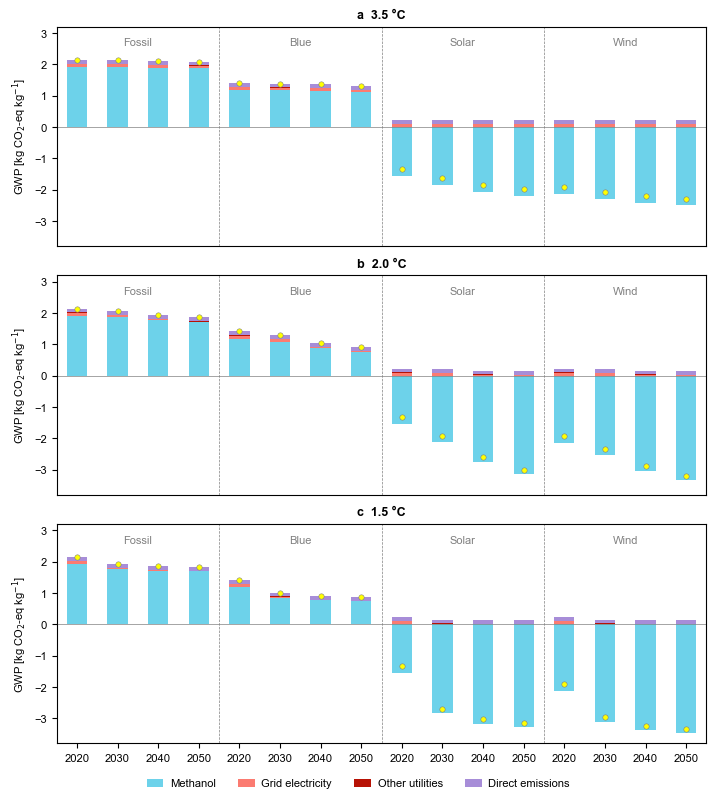

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (fig_length[2], fig_height*0.8))

xPts = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

ethylene_breakdown_plots(ethyleneRCP6DF, ax1)
ax1.xaxis.set_ticks_position('none')
ax1.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax1.set_title('a  3.5 °C', color = 'black', fontsize = fontsize_title, fontweight = 'bold')
ax1.set_xticks([])

ethylene_breakdown_plots(ethyleneRCP26DF, ax2)
ax2.xaxis.set_ticks_position('none')
ax2.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax2.set_title('b  2.0 °C', color = 'black', fontsize = fontsize_title, fontweight = 'bold')
ax2.set_xticks([])

ethylene_breakdown_plots(ethyleneRCP19DF, ax3)
ax3.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax3.set_title('c  1.5 °C', color = 'black', fontsize = fontsize_title, fontweight = 'bold')
ax3.set_xticks(xPts)  
ax3.set_xticklabels(['2020', '2030', '2040', '2050']*4, rotation = 0, ha = 'center')  

handles, labels = ax3.get_legend_handles_labels()
legend = fig.legend(handles, labels, loc = 'lower center', bbox_to_anchor = (0.5, -0.03), frameon = False, ncol = 4, handletextpad = 0.1)
for i in range(0, len(legend.legend_handles)):
    legend.legend_handles[i].set_width(12)

filepath = os.path.join('..', 'Plots', 'Phase 2', 'Breakdown', 'Ethylene image SSP2 GLO')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)